# Question & Background Information

This dataset comes from Kaggle and is compiled as part of the Abracadabra project. It contains approximately 550,000 Spotify tracks with lyrics, emotion labels, and audio features per song including tempo, energy, danceability, acousticness, and more. The dataset has 39 columns and utilizes a wide range of songs.

**Our central question is: how well can audio features predict if a song is good for studying/doing work?** This is important because platforms like Spotify heavily rely on audio characteristics to suggest and curate playlist recommendations for users based on their mood and listening habits.

If audio features can reliably predict whether a song is good for students to use while studying or completing work, Spotify would greatly benefit from the success. This success would lead to ultimately more subscriptions and listening hours. Studies have shown that when a student listens to 'good study music' their productivity will increase and they will get more work done compared to when students listen to distracting or even no music at all. For example, slower tempo, and low danceability can put a student in the 'locked-in' zone. When in contrast, fast moving songs that are 'Good for Party' would lead a student to become distracted and have poor work productivity. By identifying these patterns, recommendation algorithms can generate playlists for users such as 'study mode' or 'in the library' with greater precision.

https://www.nu.edu/blog/can-music-help-you-study-and-focus/

At the same time, personal experience does play an important role in music and how individuals utilize songs in different settings. This may not be captured in the data. This means that while audio features may provide useful signals about songs, they likely offer an incomplete picture of how truly good a song is for studying/doing work. This is a potential shortcoming of this project since we are just focusing on data and predictions. 

We will explore this question of if audio features can predict if a song is good for studying or not and what features best influence this decision to find if we can create a model to accurately predict this binary classification. We want to see if data alone, not accounting for personal experience, can classify songs correctly.

We will approach this with three main models:
1. **Logistic Regression**: supervised exploration of whether songs can be classified as good for study or not
2. **Decision Tree**: a formal classification model to predict if a song is good for studying
3. **Random Forest**: averaging multiple decision trees to provide better generalization on data

# Imports and Load Data 

In [1]:
#load libraries
import kagglehub
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split  
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score, ConfusionMatrixDisplay 
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold

/workspaces/ML_Final_Project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load the dataset from Kaggle
path = kagglehub.dataset_download("devdope/900k-spotify")

# Load the specific CSV from that path
# The file in this dataset is named 'spotify_dataset.csv'
df = pd.read_csv(f"{path}/spotify_dataset.csv")

print(df.head())

  Artist(s)                       song  \
0       !!!  Even When the Waters Cold   
1       !!!         One Girl / One Boy   
2       !!!          Pardon My Freedom   
3       !!!                        Ooo   
4       !!!                 Freedom 15   

                                                text Length  emotion    Genre  \
0  Friends told her she was better off at the bot...  03:47  sadness  hip hop   
1  Well I heard it, playing soft From a drunken b...  04:03  sadness  hip hop   
2  Oh my god, did I just say that out loud? Shoul...  05:51      joy  hip hop   
3  [Verse 1] Remember when I called you on the te...  03:44      joy  hip hop   
4  [Verse 1] Calling me like I got something to s...  06:00      joy  hip hop   

           Album       Release Date     Key  Tempo  ...  \
0       Thr!!!er    29th April 2013   D min    105  ...   
1       Thr!!!er    29th April 2013  A# min    117  ...   
2  Louden Up Now      8th June 2004   A Maj    121  ...   
3          As If  16th O

# EDA

In [3]:
# explore the dataset's columns, non-null count, and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 551443 entries, 0 to 551442
Data columns (total 39 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Artist(s)                       551443 non-null  str    
 1   song                            551427 non-null  str    
 2   text                            551443 non-null  str    
 3   Length                          551443 non-null  str    
 4   emotion                         551443 non-null  str    
 5   Genre                           551443 non-null  str    
 6   Album                           551391 non-null  str    
 7   Release Date                    551443 non-null  str    
 8   Key                             551443 non-null  str    
 9   Tempo                           551443 non-null  int64  
 10  Loudness (db)                   551443 non-null  str    
 11  Time signature                  551435 non-null  str    
 12  Explicit                   

In [4]:
# get a summary statistics of the dataset
df.describe()

,Tempo,Popularity,Energy,Danceability,Positiveness,Speechiness,Liveness,Acousticness,Instrumentalness,Good for Party,...,Good for Relaxation/Meditation,Good for Exercise,Good for Running,Good for Yoga/Stretching,Good for Driving,Good for Social Gatherings,Good for Morning Routine,Similarity Score 1,Similarity Score 2,Similarity Score 3
count,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,...,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000,551443.000000
mean,120.513567,32.258106,62.661874,59.195460,47.738330,11.663980,19.655658,25.748436,7.152255,0.061809,...,0.030772,0.187334,0.053842,0.021484,0.057797,0.012253,0.066215,0.984107,0.979013,0.975938
std,29.185533,18.033931,22.399159,17.511007,24.159671,12.342389,16.274817,29.343731,20.589200,0.240808,...,0.172700,0.390180,0.225707,0.144990,0.233360,0.110014,0.248658,0.013559,0.015438,0.016512
min,31.000000,0.000000,0.000000,6.000000,0.000000,2.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002656,0.002647,0.002647
25%,97.000000,20.000000,48.000000,47.000000,28.000000,4.000000,10.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.977433,0.971582,0.967926
50%,120.000000,30.000000,65.000000,60.000000,47.000000,6.000000,13.000000,12.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.985926,0.980971,0.978078
75%,140.000000,43.000000,80.000000,72.000000,66.000000,15.000000,25.000000,43.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.993567,0.988592,0.986079
max,200.000000,100.000000,100.000000,99.000000,100.000000,97.000000,100.000000,100.000000,100.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
# see the total na values in each column
df.isna().sum()

Artist(s)                          0
song                              16
text                               0
Length                             0
emotion                            0
Genre                              0
Album                             52
Release Date                       0
Key                                0
Tempo                              0
Loudness (db)                      0
Time signature                     8
Explicit                           0
Popularity                         0
Energy                             0
Danceability                       0
Positiveness                       0
Speechiness                        0
Liveness                           0
Acousticness                       0
Instrumentalness                   0
Good for Party                     0
Good for Work/Study                0
Good for Relaxation/Meditation     0
Good for Exercise                  0
Good for Running                   0
Good for Yoga/Stretching           0
G

In [6]:
# print column names for easy reference
print(df.columns)

Index(['Artist(s)', 'song', 'text', 'Length', 'emotion', 'Genre', 'Album',
       'Release Date', 'Key', 'Tempo', 'Loudness (db)', 'Time signature',
       'Explicit', 'Popularity', 'Energy', 'Danceability', 'Positiveness',
       'Speechiness', 'Liveness', 'Acousticness', 'Instrumentalness',
       'Good for Party', 'Good for Work/Study',
       'Good for Relaxation/Meditation', 'Good for Exercise',
       'Good for Running', 'Good for Yoga/Stretching', 'Good for Driving',
       'Good for Social Gatherings', 'Good for Morning Routine',
       'Similar Artist 1', 'Similar Song 1', 'Similarity Score 1',
       'Similar Artist 2', 'Similar Song 2', 'Similarity Score 2',
       'Similar Artist 3', 'Similar Song 3', 'Similarity Score 3'],
      dtype='str')


In [7]:
# drop columns not needed for analysis
# some columns have many missing values and others are just not relevent or bring too much noice so will be dropped
df = df.drop(columns=['song', 'text', 'Length', 'Genre', 'Album', 'Release Date', 'Artist(s)', 'Popularity', 'Liveness', 'Similar Artist 1', 'Similar Artist 2', 'Similar Artist 3', 'Similar Song 1', 'Similar Song 2', 'Similar Song 3', 'Similarity Score 1', 'Similarity Score 2', 'Similarity Score 3'])
# drop all the 'Good for ___' columns due to data leakage concerns except the target variable 'Good for Work/Study' because will drop later after creating target variable
df = df.drop(columns=['Good for Party', 'Good for Relaxation/Meditation', 'Good for Exercise', 'Good for Running', 'Good for Yoga/Stretching', 'Good for Driving', 'Good for Social Gatherings', 'Good for Morning Routine'])
# confirm the columns have been dropped
df.columns

Index(['emotion', 'Key', 'Tempo', 'Loudness (db)', 'Time signature',
       'Explicit', 'Energy', 'Danceability', 'Positiveness', 'Speechiness',
       'Acousticness', 'Instrumentalness', 'Good for Work/Study'],
      dtype='str')

In [8]:
# check for missing values again after dropping columns
df.isna().sum()

emotion                0
Key                    0
Tempo                  0
Loudness (db)          0
Time signature         8
Explicit               0
Energy                 0
Danceability           0
Positiveness           0
Speechiness            0
Acousticness           0
Instrumentalness       0
Good for Work/Study    0
dtype: int64

In [9]:
# Drop rows with missing values in the remaining columns
# We can do this becuase 8 rows is not a significant portion of the dataset
df = df.dropna()
#confirm the missing values have been dropped
df.isna().sum()

emotion                0
Key                    0
Tempo                  0
Loudness (db)          0
Time signature         0
Explicit               0
Energy                 0
Danceability           0
Positiveness           0
Speechiness            0
Acousticness           0
Instrumentalness       0
Good for Work/Study    0
dtype: int64

For the categorical columns, do additional cleaning on them:

In [10]:
# view value counts of emotion column and print the number of unique values
print(df['emotion'].nunique())
print(df['emotion'].value_counts())

13
emotion
joy          209006
sadness      171073
anger        109678
fear          28097
love          27963
surprise       5592
True             17
Love              3
pink              2
angry             1
thirst            1
confusion         1
interest          1
Name: count, dtype: int64


In [11]:
# Clean up the emotion column more to ensure consistency and collapse rare emotions into other
df['emotion'] = df['emotion'].replace('Love','love')
df['emotion'] = df['emotion'].replace('angry','anger')
df['emotion'] = df['emotion'].replace(['surprise', 'True', 'pink', 'thirst', 'confusion', 'interest'],'other')
# view value counts of emotion column and print the number of unique values after cleaning
print(df['emotion'].nunique())
print(df['emotion'].value_counts())

6
emotion
joy        209006
sadness    171073
anger      109679
fear        28097
love        27966
other        5614
Name: count, dtype: int64


In [12]:
# view value counts of key column and print the number of unique values
print(df['Key'].nunique())
print(df['Key'].value_counts())

24
Key
C Maj     47744
G Maj     47464
D Maj     44568
C# Maj    44409
A Maj     33849
G# Maj    26045
B min     25772
E min     22348
F Maj     22298
A min     21093
A# min    20260
B Maj     19762
E Maj     19633
F# min    19529
F# Maj    19468
F min     19073
C# min    18583
A# Maj    16250
G min     14558
C min     12224
D min     10455
G# min    10293
D# Maj     9233
D# min     6524
Name: count, dtype: int64


Some research showed that the major and minor is more meaningful than individual key names for impacting the mood of a listener

https://www.theamericanguitaracademy.com/post/understanding-major-vs-minor-in-music 

In [13]:
# collapse into 2 categories: Major or Minor
# first make it all lower case to ensure consistency
# then use .apply to create a funciton so if it contains 'maj' it will be categorized as 'major', and if not it will be 'minor'
df['Key'] = df['Key'].str.lower().apply(lambda x: 'major' if 'maj' in x else 'minor')
# view value counts of key column and print the number of unique values after collapsing
print(df['Key'].nunique())
print(df['Key'].value_counts())

2
Key
major    350723
minor    200712
Name: count, dtype: int64


In [14]:
# view value counts of Loudness (db) column and print the number of unique values adn the column type
print(df['Loudness (db)'].nunique())
print(df['Loudness (db)'].value_counts())
print(df['Loudness (db)'].dtype)

3746
Loudness (db)
-6db        10611
-7db         8986
-5db         8221
-8db         7010
-4db         6528
            ...  
3.64db          1
-47.06db        1
-36.07db        1
-28.62db        1
-43.72db        1
Name: count, Length: 3746, dtype: int64
str


In [15]:
# strip the 'db' from the Loudness (db) column and convert to numeric
df['Loudness (db)'] = df['Loudness (db)'].str.replace('db', '').astype(float)

In [16]:
# verify dtype and that the values have been converted to numeric correctly
print(df['Loudness (db)'].dtype)
print(df['Loudness (db)'].sort_values(ascending=False).head(5))
print(df['Loudness (db)'].sort_values(ascending=True).head(5))

float64
1276      4.98
511697    4.11
527718    3.78
486936    3.74
486911    3.74
Name: Loudness (db), dtype: float64
416315   -50.06
416316   -50.06
416318   -50.06
416314   -50.06
335646   -48.76
Name: Loudness (db), dtype: float64


In [17]:
# view value counts of Explicit column and print the number of unique values
print(df['Explicit'].nunique())
print(df['Explicit'].value_counts())

2
Explicit
No     389374
Yes    162061
Name: count, dtype: int64


Understand the class balance of the target with the prevalence

In [18]:
# get the number of unique values in the target variable and the count of each value
print(df['Good for Work/Study'].nunique())
print(df['Good for Work/Study'].value_counts())

2
Good for Work/Study
0    510118
1     41317
Name: count, dtype: int64


In [19]:
# calculate the prevalence of the target variable
prevalence = (41317/(510118+41317))
print(f"Prevalence of Good for Work/Study: {prevalence:.4f}")

Prevalence of Good for Work/Study: 0.0749


This is concerning as it is very unbalanced.

Thought Process: Need to straftify the test/train and run class_weight = balanced on models

### Graphs with an Emphasis on Variables we Believe to be Important For Analysis

In [20]:
# print the datatypes of df
print(df.dtypes)

emotion                    str
Key                        str
Tempo                    int64
Loudness (db)          float64
Time signature             str
Explicit                   str
Energy                   int64
Danceability             int64
Positiveness             int64
Speechiness              int64
Acousticness             int64
Instrumentalness         int64
Good for Work/Study      int64
dtype: object


<Axes: >

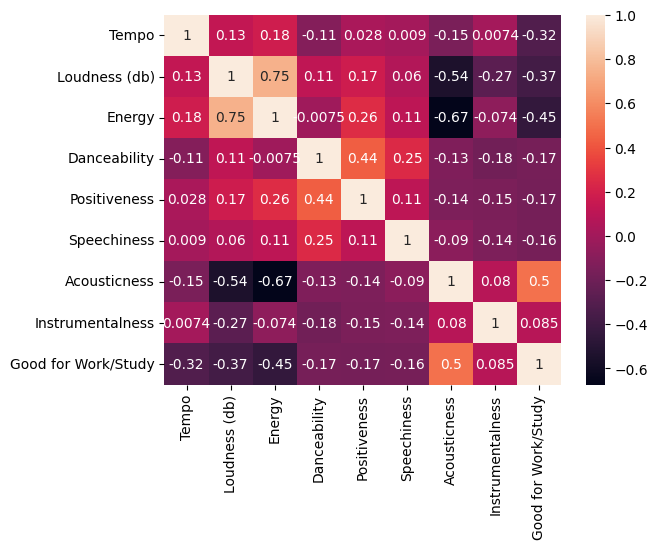

In [22]:
# print a correlation matrix only using the numeric data types in df
numeric_features = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_features.corr()
sns.heatmap(corr_matrix, annot=True)

Seems like energy and loudness have high correlation but not too high to be worried about multicollinearity.

Good for study also looks to corrlate with acousticness. This tells us that that may be a good factor to predicit off of.

In [23]:
# create x and y dataset for modeling
#target variable
y = df['Good for Work/Study']

# drop target variable from X dataset along 
X = df.drop(columns=['Good for Work/Study'])

In [24]:
# make sure Good for Work/Study is dropped from X dataset
print(X.columns)
# print the shape of X and y to confirm they are the same length
print(X.shape)
print(y.shape)

Index(['emotion', 'Key', 'Tempo', 'Loudness (db)', 'Time signature',
       'Explicit', 'Energy', 'Danceability', 'Positiveness', 'Speechiness',
       'Acousticness', 'Instrumentalness'],
      dtype='str')
(551435, 12)
(551435,)


In [25]:
# create categorical features 
categorical_features = X.select_dtypes(include=['str'])
# re-run numeric_features to prevent errors  
numeric_features = X.select_dtypes(include=['int64', 'float64'])

In [26]:
# print the datatypes of X once more to check again
print(X.dtypes)

emotion                 str
Key                     str
Tempo                 int64
Loudness (db)       float64
Time signature          str
Explicit                str
Energy                int64
Danceability          int64
Positiveness          int64
Speechiness           int64
Acousticness          int64
Instrumentalness      int64
dtype: object


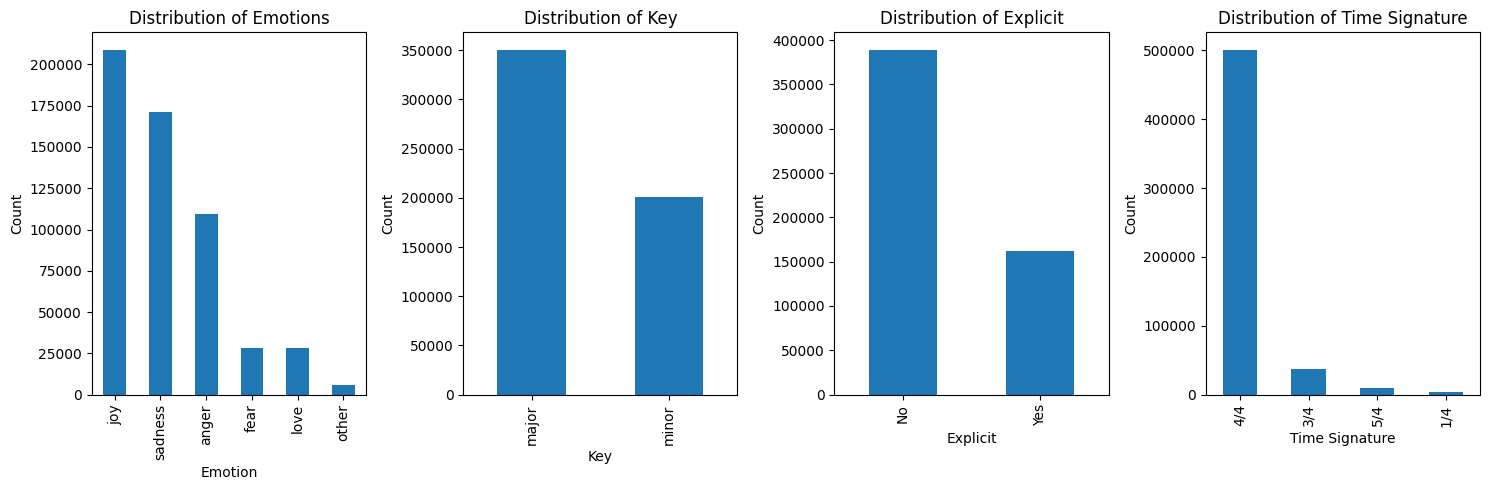

In [27]:
# see the distribution of the categorical features, start with emotion then do Key and Explicit and Time Signiture

plt.figure(figsize=(15,5))

# Emotion
plt.subplot(1,4,1)
categorical_features['emotion'].value_counts().plot(kind='bar')
plt.title("Distribution of Emotions")
plt.xlabel("Emotion")
plt.ylabel("Count")

# Key
plt.subplot(1,4,2)
categorical_features['Key'].value_counts().plot(kind='bar')
plt.title("Distribution of Key")
plt.xlabel("Key")
plt.ylabel("Count")

# Explicit
plt.subplot(1,4,3)
categorical_features['Explicit'].value_counts().plot(kind='bar')
plt.title("Distribution of Explicit")
plt.xlabel("Explicit")
plt.ylabel("Count")

#Time signature
plt.subplot(1,4,4)
categorical_features['Time signature'].value_counts().plot(kind='bar')
plt.title("Distribution of Time Signature")
plt.xlabel("Time Signature")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

- joy and sadness really take over the emotion cat
- major and minor are somewhat balenced
- most of the songs are not explicit
- 4/4 time signiture is really dominating

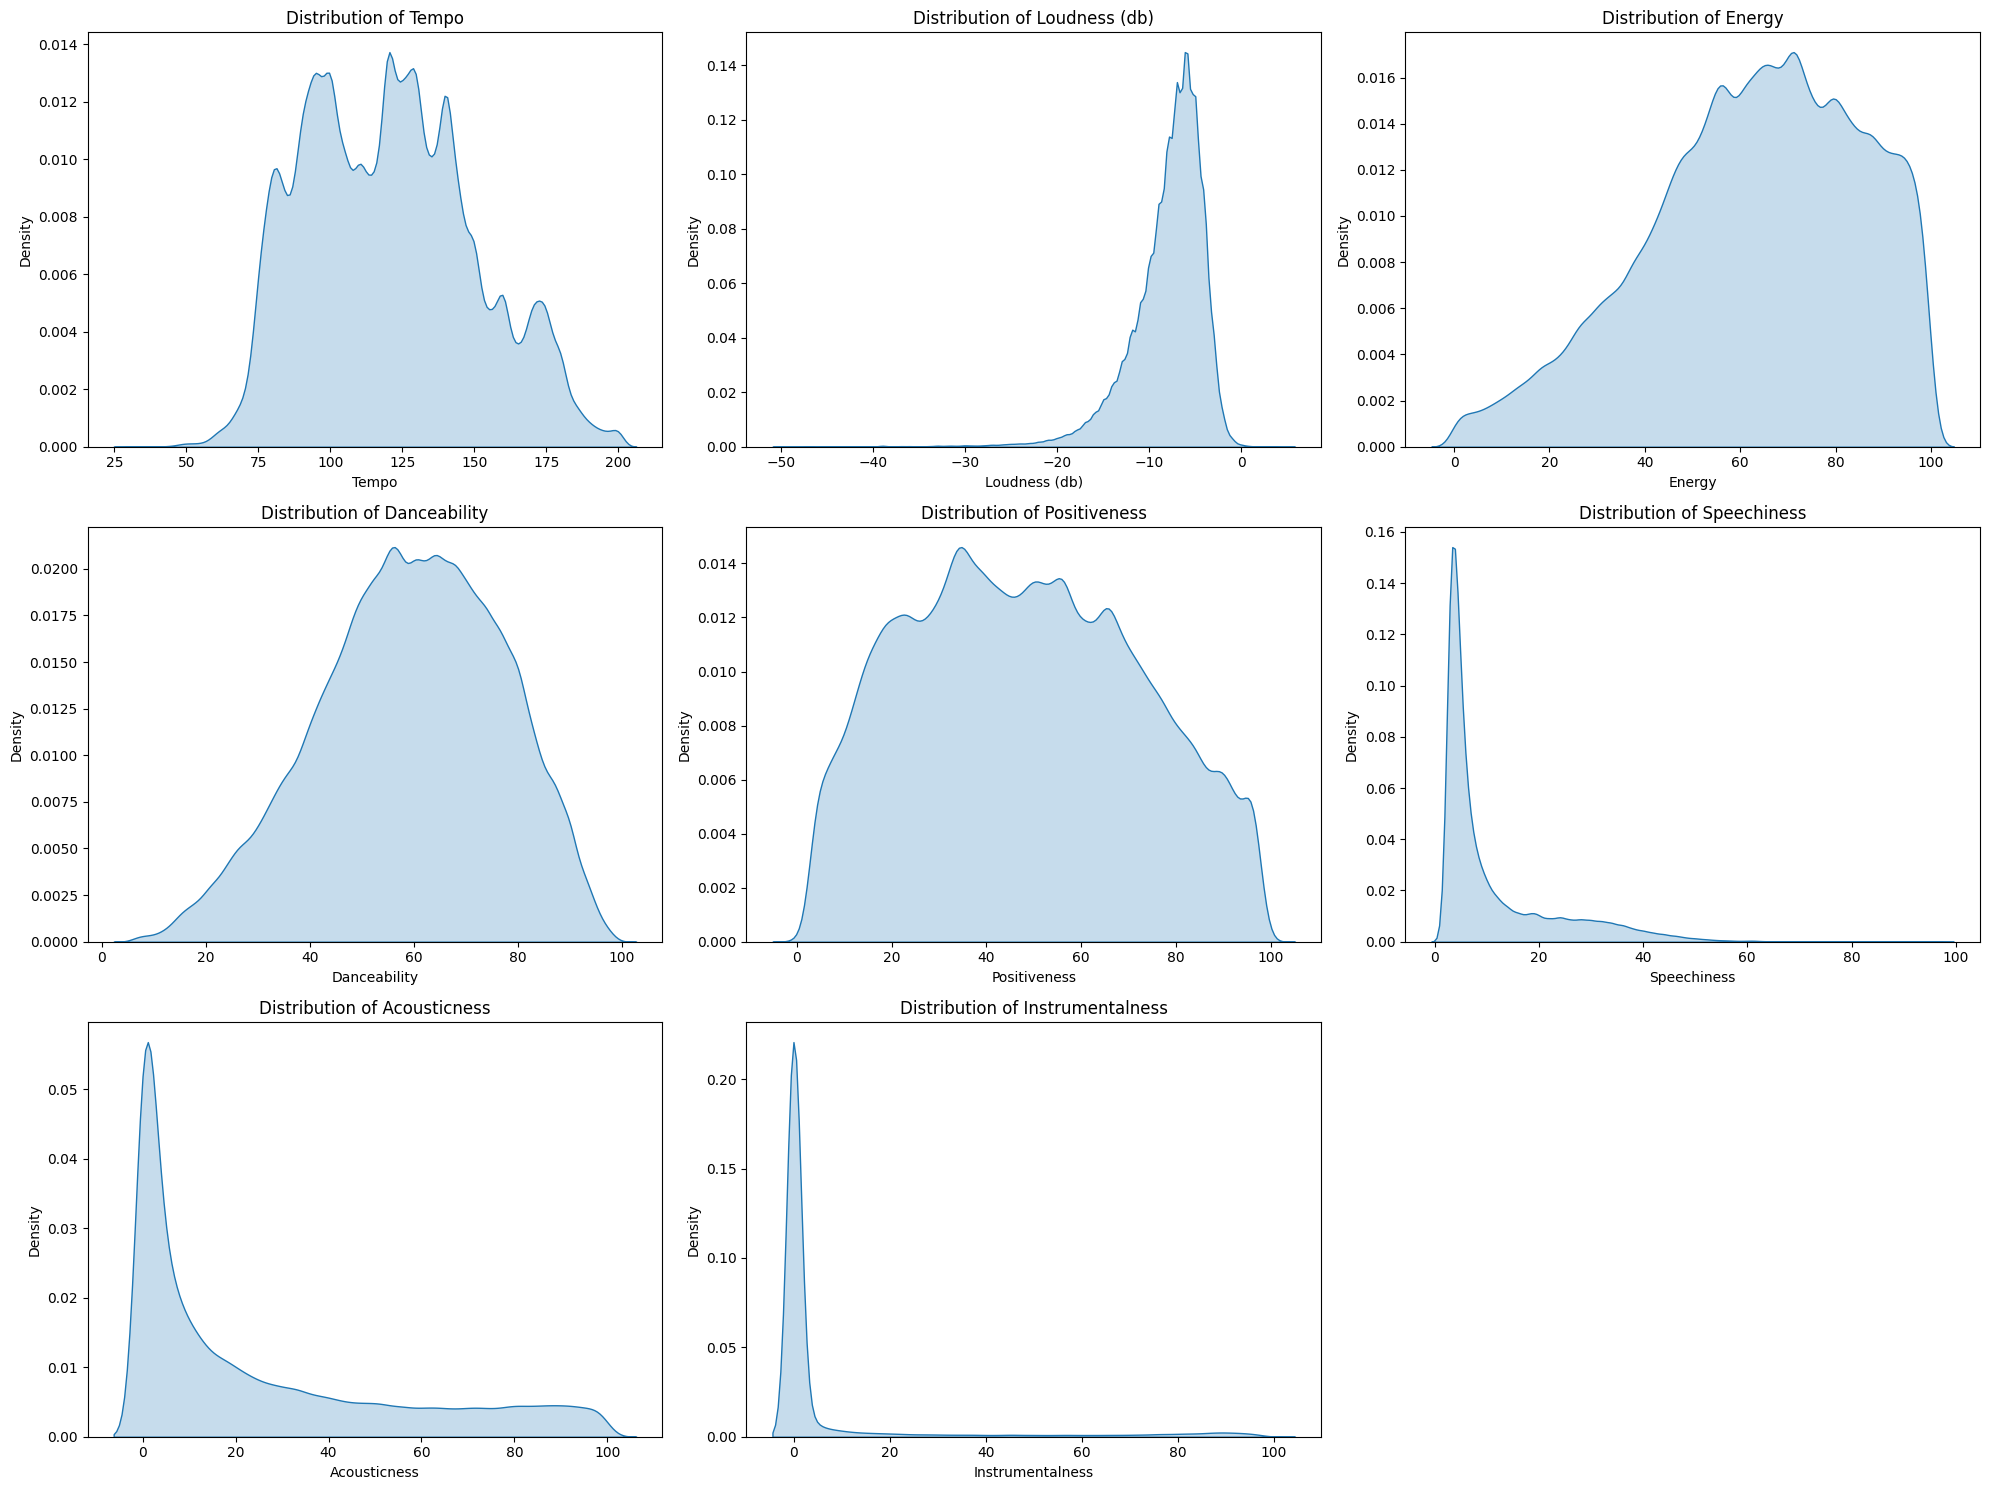

In [29]:
# see kde plots of the numeric features to see their distribution and if there are any outliers
# make a loop though beucase its too long to do this manually

num_cols = numeric_features.shape[1]

plt.figure(figsize=(20, 15))

for i in range(num_cols):
    col = numeric_features.columns[i]
    plt.subplot(3, 3, i + 1)
    sns.kdeplot(numeric_features[col], fill=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Density")

plt.tight_layout()
plt.show()

Speechiness, acousticness, and instrumentalness are heavily right-skewed, so we apply a log transformation to reduce extreme values and make the data more stable for logistic regression.

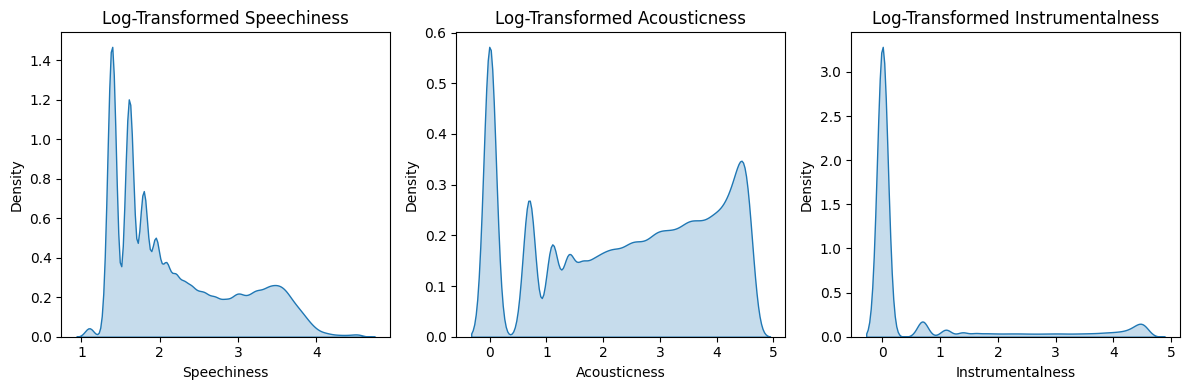

In [30]:
cols = ['Speechiness', 'Acousticness', 'Instrumentalness']

# log transform
for col in cols:
    X[col] = np.log1p(X[col])

# plot
plt.figure(figsize=(12, 4))

for i in range(len(cols)):
    col = cols[i]
    plt.subplot(1, 3, i + 1)
    sns.kdeplot(X[col], fill=True)
    plt.title(f"Log-Transformed {col}")
    plt.xlabel(col)
    plt.ylabel("Density")

plt.tight_layout()
plt.show()

The log transformation reduced skew and made the data more balanced, but many values are still near zero because many songs naturally have low levels of these features. This could still help the model make better predictions though

# Methods & Evaluations of Models

## Model 1 - Logistic Regression - solver='lbfgs' - class_weight=None


In [31]:
# make x and y
# make categorical_features and numerical_features into a list of column names not DataFrames
# add this here again to prevent error
categorical_features = X.select_dtypes(include=['str'])
categorical_features = categorical_features.columns.tolist()
# add this here again to prevent error
numeric_features = X.select_dtypes(include=['int64', 'float64'])
numeric_features = numeric_features.columns.tolist()
x = X[categorical_features + numeric_features]
y = df['Good for Work/Study']
print(X.head())
print(y.head())

   emotion    Key  Tempo  Loudness (db) Time signature Explicit  Energy  \
0  sadness  minor    105          -6.85            4/4       No      83   
1  sadness  minor    117          -5.75            4/4       No      85   
2      joy  major    121          -6.06            4/4       No      89   
3      joy  minor    122          -5.42            4/4       No      84   
4      joy  minor    123          -5.57            4/4       No      71   

   Danceability  Positiveness  Speechiness  Acousticness  Instrumentalness  
0            71            87     1.609438      2.484907          0.000000  
1            70            87     1.609438      0.000000          0.000000  
2            71            63     2.197225      0.000000          3.044522  
3            78            97     1.609438      2.564949          0.000000  
4            77            70     2.079442      1.609438          0.693147  
0    0
1    0
2    0
3    0
4    0
Name: Good for Work/Study, dtype: int64


In [32]:
# Train / test split — 80/20, stratified so class ratios are preserved 
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [33]:
# prepreocessing the column transformer step
# transform categorical features by onehotencoding them and minmaxscale the numeric features
X_raw = ColumnTransformer(
    transformers=[
        ('categorical_features', OneHotEncoder(handle_unknown='ignore'), categorical_features), 
        ('numeric_features', StandardScaler(), numeric_features)
    ])

# create pipeline with X_raw and logistic regression as the model
pipeline1 = Pipeline(steps=[
    ('prep', X_raw),
    ('model', LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42))
])


# fit the data into pipeline so that it transforms the data and fits it properly
pipeline1.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical_features', ...), ('numeric_features', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the dif

## Model Evaluation 

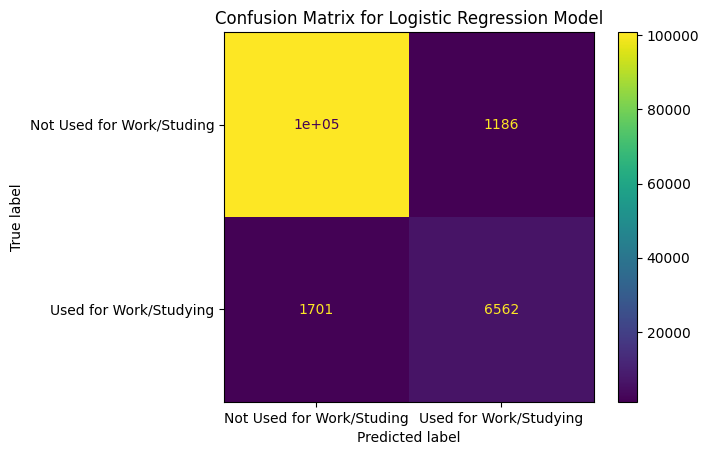

                           precision    recall  f1-score   support

Not Used for Work/Studing       0.98      0.99      0.99    102024
   Used for Work/Studying       0.85      0.79      0.82      8263

                 accuracy                           0.97    110287
                macro avg       0.92      0.89      0.90    110287
             weighted avg       0.97      0.97      0.97    110287



In [34]:
# use the pipeline to predict on the test set and then create a confusion matrix and classification report to evaluate the model performance
# predict 
y_pred_1 = pipeline1.predict(X_test)
# create confusion matrix and classification report
confusion_matrix1 = confusion_matrix(y_test, y_pred_1)
# create the display of the confusion matrix 
disp1 = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix1, display_labels=['Not Used for Work/Studing', 'Used for Work/Studying'])
# plot it 
disp1.plot()
plt.title('Confusion Matrix for Logistic Regression Model')
plt.show()
#print classification report with correct target names
print(classification_report(y_test, y_pred_1, target_names=['Not Used for Work/Studing', 'Used for Work/Studying']))

### Confusion Matrix & Classification Report analysis

This logistic regression model achieved an overall accuracy of 97%. It performed 
very well on "Not Used for Work/Studying" songs with a precision of 0.98 and recall of 
0.99, meaning it correctly identified almost all non-study songs.

However it struggled more with "Used for Work/Studying" songs, with a precision of 0.85 
and recall of 0.79. This means it missed 1,699 study music songs (false negatives) and 
incorrectly flagged 1,189 non-study songs as study music (false positives).

This is expected behavior for a basic logistic regression model without class balancing — 
it leans toward predicting the majority class. 

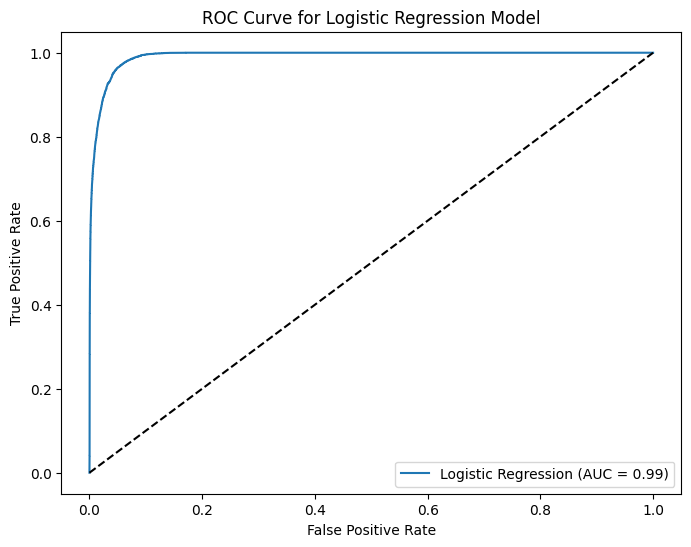

Model 1 ROC-AUC: 0.9916


In [35]:
# create a ROC curve and calculate the AUC score for the model using the pipeline to predict probabilities on the test set
fpr1, tpr1, threshold1 = roc_curve(y_test, pipeline1.predict_proba(X_test)[:, 1])
auc1 = roc_auc_score(y_test, pipeline1.predict_proba(X_test)[:, 1])
plt.figure(figsize=(8, 6))
# plot it 
plt.plot(fpr1, tpr1, label=f'Logistic Regression (AUC = {auc1:.2f})')
# plot the diagonal line for reference
plt.plot([0, 1], [0, 1], 'k--') 
# add labels and a title and legend 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression Model')
plt.legend()
plt.show()
# print the AUC score for the model
print(f"Model 1 ROC-AUC: {auc1:.4f}")

 ### ROC Curve anlysis

Model 1 achieved an AUC of 0.99, which is excellent. The curve rises steeply toward 
the top left corner, meaning the model does a great job separating study music from 
non-study music. This is consistent with the high overall accuracy seen in the 
classification report.

## Model 2 - Logistic Regression - solver='saga' - class_weight='balanced'

We are using the saga solver because in a previous lab it was noted that this solver worked better on larger datasets. It is important to use "balanced" because we previously identified that the prevalence was very low at 7%.

In [36]:
# create pipeline with column transformer and logistic regression model
# use solver = 'saga' and class_weight='balanced'
pipeline2 = Pipeline(steps=[
    ('prep', X_raw),
    ('model', LogisticRegression(max_iter=1000, solver='saga', class_weight='balanced', random_state=42))
])


# fit the data into pipeline
pipeline2.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical_features', ...), ('numeric_features', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the dif

## Model 2 Evaluation 

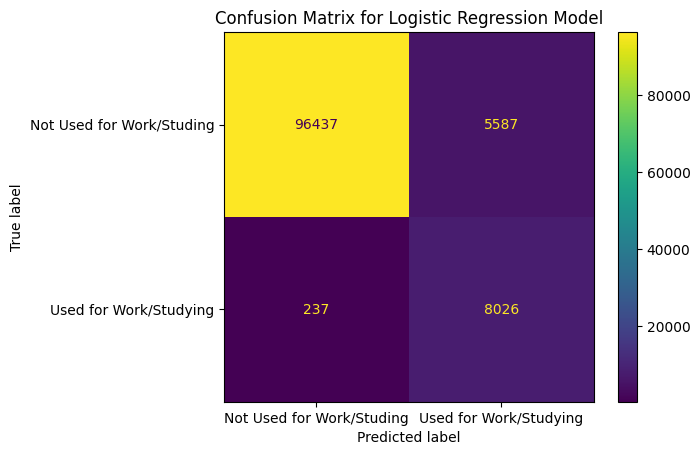

                           precision    recall  f1-score   support

Not Used for Work/Studing       1.00      0.95      0.97    102024
   Used for Work/Studying       0.59      0.97      0.73      8263

                 accuracy                           0.95    110287
                macro avg       0.79      0.96      0.85    110287
             weighted avg       0.97      0.95      0.95    110287



In [37]:
# use the pipeline to predict on the test set and then create a confusion matrix and classification report to evaluate the model performance
# predict 
y_pred_2 = pipeline2.predict(X_test)
# create confusion matrix and classification report
confusion_matrix2 = confusion_matrix(y_test, y_pred_2)
# create the display of the confusion matrix 
disp1 = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix2, display_labels=['Not Used for Work/Studing', 'Used for Work/Studying'])
# plot it 
disp1.plot()
plt.title('Confusion Matrix for Logistic Regression Model')
plt.show()
#print classification report with correct target names
print(classification_report(y_test, y_pred_2, target_names=['Not Used for Work/Studing', 'Used for Work/Studying']))

### Confusion Matrix & Classification Report analysis

Adding class_weight='balanced' improved the model's ability to correctly identify study 
music songs, with recall jumping from 0.79 to 0.97. However this came at a cost — 
precision dropped to 0.59, meaning more non-study songs were incorrectly flagged. 
Overall accuracy came in at 0.95.

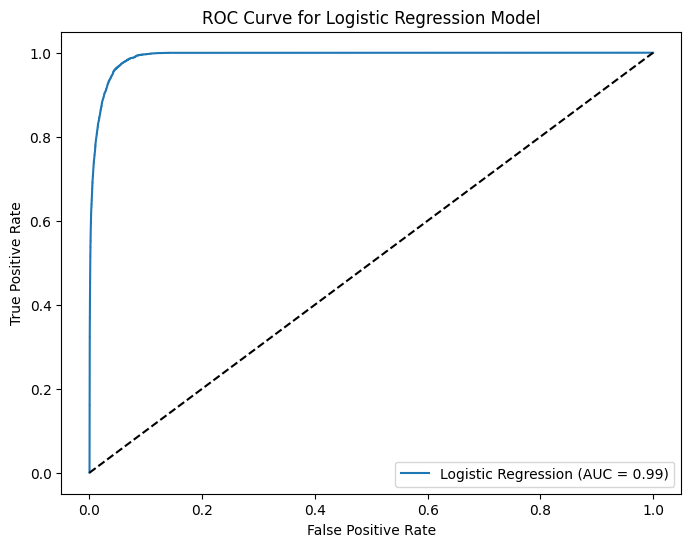

Model 2 ROC-AUC: 0.9916


In [38]:
# create a ROC curve and calculate the AUC score for the model using the pipeline to predict probabilities on the test set
fpr2, tpr2, threshold2 = roc_curve(y_test, pipeline2.predict_proba(X_test)[:, 1])
auc2 = roc_auc_score(y_test, pipeline2.predict_proba(X_test)[:, 1])
plt.figure(figsize=(8, 6))
# plot it 
plt.plot(fpr2, tpr2, label=f'Logistic Regression (AUC = {auc2:.2f})')
# plot the diagonal line for reference
plt.plot([0, 1], [0, 1], 'k--') 
# add labels and a title and legend 
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression Model')
plt.legend()
plt.show()
# print the AUC score for the model
print(f"Model 2 ROC-AUC: {auc2:.4f}")

### ROC Curve analysis

Model 2 achieved the same AUC of 0.99 as Model 1, confirming that both models are 
equally strong at separating the two classes. The difference between the models shows 
up in the confusion matrix rather than the ROC curve.

## Model 1 vs Model 2 - Logistic Regression Comparison

Changing the solver to saga and adding class_weight='balanced' did not change the ROC-AUC score, which remained at 0.99 for both models. However it did shift the precision tradeoff between classes. Precision for 'Not Used for Work/Studying' improved from 0.98 to 1.00, while precision for 'Used for Work/Studying' dropped from 0.85 to 0.59. This means Model 2 is more conservative about labeling songs as study music, predicting this class less often in order to reduce false positives.

In this case, precision is more important than recall for predicting whether a song is good for studying. It is better for the model to predict that a song is not good for studying when it actually is, rather than predict that a song is good for studying when it is not. This is because false positives would introduce distracting songs into a study playlist, which would negatively impact the listener’s focus and productivity.

This relates back to our central question because even though the model can identify patterns in audio features, it must be careful about when it labels a song as “good for studying.” A more conservative model, like the balanced version, may miss some good study songs, but it creates a more reliable and less distracting listening experience overall.

## Model 3 - Decision Tree

In [39]:
# Cross Validation
kf = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)
# only need 5 splits because the dataset is so big

In [40]:
from sklearn.metrics import get_scorer_names
#print potential ones and pic the ones that are most relevant to this project which are roc_auc, recall, and balanced_accuracy
print(get_scorer_names())
scoring = ['roc_auc','recall','balanced_accuracy']

['accuracy', 'adjusted_mutual_info_score', 'adjusted_rand_score', 'average_precision', 'balanced_accuracy', 'completeness_score', 'd2_absolute_error_score', 'd2_brier_score', 'd2_log_loss_score', 'explained_variance', 'f1', 'f1_macro', 'f1_micro', 'f1_samples', 'f1_weighted', 'fowlkes_mallows_score', 'homogeneity_score', 'jaccard', 'jaccard_macro', 'jaccard_micro', 'jaccard_samples', 'jaccard_weighted', 'matthews_corrcoef', 'mutual_info_score', 'neg_brier_score', 'neg_log_loss', 'neg_max_error', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error', 'neg_mean_gamma_deviance', 'neg_mean_poisson_deviance', 'neg_mean_squared_error', 'neg_mean_squared_log_error', 'neg_median_absolute_error', 'neg_negative_likelihood_ratio', 'neg_root_mean_squared_error', 'neg_root_mean_squared_log_error', 'normalized_mutual_info_score', 'positive_likelihood_ratio', 'precision', 'precision_macro', 'precision_micro', 'precision_samples', 'precision_weighted', 'r2', 'rand_score', 'recall', 'recall_m

In [41]:
# decision trees need categories as numbers, so we encode them
# numeric columns pass through unchanged
dt_prep = ColumnTransformer(transformers=[
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_features),
    ('num', 'passthrough', numeric_features)
])
#use ordinal encoding because decision trees can handle categorical features as numbers and it is more efficient than onehotencoding for this model

run the model with bare minimum to see what the tree natrually does without setting strong perameters yet

In [42]:
# create the pipeline using class_weight=balanced and DecisionTreeClassifier as the model
pipe_dt1 = Pipeline([
    ('prep', dt_prep),
    ('classifier', DecisionTreeClassifier(class_weight='balanced', random_state=42))
])

# create variable param1 to determine which max_depth will be the best
param1 = {"classifier__max_depth": [1, 2, 3, 4, 5, 6, 7]}

# use GridSearchCV on the pipeline with the parameters to determine the best max_depth
#scoring=scoring because earlier we defined the variable as scoring = ['roc_auc','recall','balanced_accuracy'] so it chooses the best parameter based on those metrics, but the final model is selected based on refit=roc_auc
#n_jobs=-1 means it will use all available CPU cores for faster computation
#cv=kf because earlier we defined kf as kf = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)so it evaluates it 10 times since we did 5 folds repeated twice
#refit='roc_auc' because after testing all models it will pick the one with the best ROC AUC score and then refit it on the full training data
search1 = GridSearchCV(pipe_dt1, param1, scoring=scoring, n_jobs=-1, cv=kf, refit='roc_auc')
model_dt1 = search1.fit(X_train, y_train)

# find the best trained model during the grid search
best_dt1 = model_dt1.best_estimator_
print(best_dt1)
print("\n")
# from that model, extract just the decision tree model itself 
best_clf1 = best_dt1.named_steps['classifier']
print(best_clf1)
print("\n")
# get the best hyperparameters found during GridSearchCV so what is the best classifier_max_depth
print('best params:', model_dt1.best_params_)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['emotion', 'Key',
                                                   'Time signature',
                                                   'Explicit']),
                                                 ('num', 'passthrough',
                                                  ['Tempo', 'Loudness (db)',
                                                   'Energy', 'Danceability',
                                                   'Positiveness',
                                                   'Speechiness',
                                                   'Acousticness',
                                                   'Instrumentalness'])])),
                ('classifier

## Model 3 Evaluation

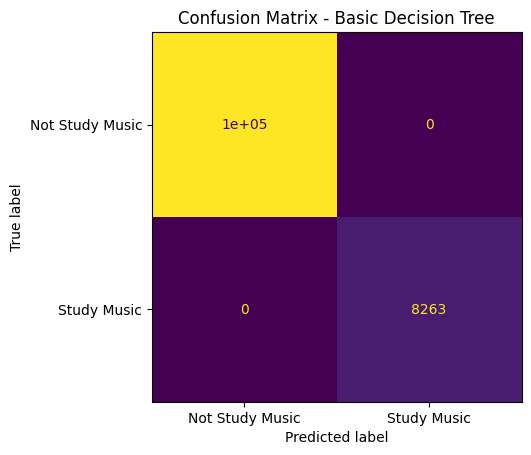

                 precision    recall  f1-score   support

Not Study Music       1.00      1.00      1.00    102024
    Study Music       1.00      1.00      1.00      8263

       accuracy                           1.00    110287
      macro avg       1.00      1.00      1.00    110287
   weighted avg       1.00      1.00      1.00    110287



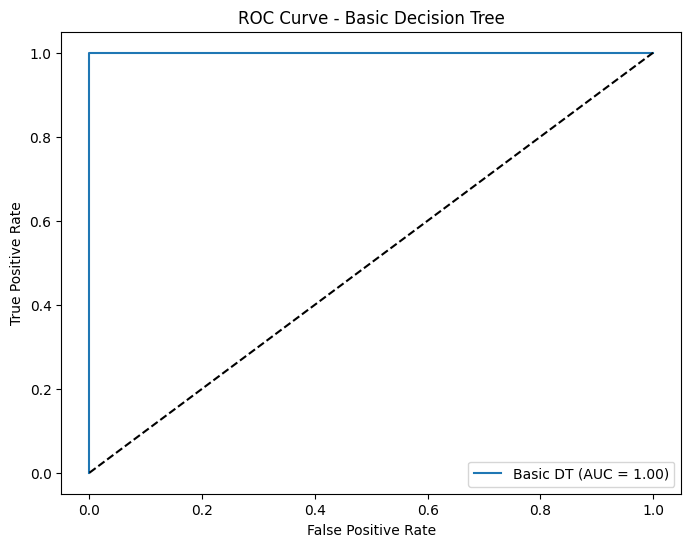

Model 3 ROC-AUC: 1.0000


In [43]:
y_pred1 = best_dt1.predict(X_test)
# get predicted probabilty of positive class by indexing for all rows and column 1 which is the positive class
y_proba1 = best_dt1.predict_proba(X_test)[:, 1]

ConfusionMatrixDisplay.from_estimator(best_dt1, X_test, y_test,
    display_labels=['Not Study Music', 'Study Music'], colorbar=False)
plt.title('Confusion Matrix - Basic Decision Tree')
plt.show()

print(classification_report(y_test, y_pred1, target_names=['Not Study Music', 'Study Music']))

fpr1, tpr1, _ = roc_curve(y_test, y_proba1)
auc1 = roc_auc_score(y_test, y_proba1)
plt.figure(figsize=(8,6))
plt.plot(fpr1, tpr1, label=f'Basic DT (AUC = {auc1:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Basic Decision Tree')
plt.legend()
plt.show()
print(f"Model 3 ROC-AUC: {auc1:.4f}")

### Performance Summary across Conusion Matrix, Classification report, and ROC curve

The confusion matrix shows zero errors across all 110,287 predictions, correctly 
classifying every study and non-study song. The classification report confirms this 
with perfect precision, recall, and F1-score of 1.00 for both classes. The ROC curve 
achieves a perfect AUC of 1.00, forming a sharp right angle in the top left corner. 
While these numbers look ideal, they are a sign of overfitting rather than a genuinely 
strong model.

### Overfitting issue

The basic decision tree overfit the training data, scoring a perfect 1.00 across all 
metrics. On a dataset of 400k songs, zero mistakes means the model is memorizing the 
data rather than learning real patterns.

To fix this, Model 2 adds `min_samples_leaf` to prevent overly specific splits, and 
`max_features` to stop the tree from always relying on acousticness at every split.

## Model 4- Decision Tree Model 

In [44]:
pipe_dt2 = Pipeline([
    ('prep', dt_prep),
    ('classifier', DecisionTreeClassifier(class_weight='balanced', random_state=42))
])

# add more parameters 
param2 = {
    "classifier__max_depth": [3, 4, 5, 6, 7, 8],
    "classifier__min_samples_leaf": [500, 1000, 2000],
    "classifier__max_features": ["sqrt", "log2"]
}

# same thing as done previously 
search2 = GridSearchCV(pipe_dt2, param2, scoring=scoring, n_jobs=-1, cv=kf, refit='roc_auc')
model_dt2 = search2.fit(X_train, y_train)

best_dt2 = model_dt2.best_estimator_
best_clf2 = best_dt2.named_steps['classifier']
print('best params:', model_dt2.best_params_)
print('leaves:', best_clf2.get_n_leaves())

best params: {'classifier__max_depth': 8, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 500}
leaves: 18


## Model 4 evaluation

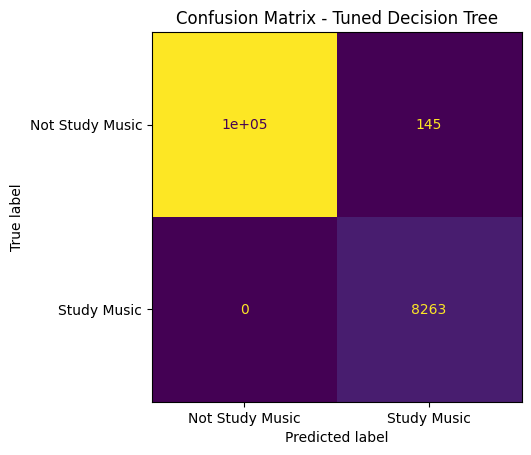

                 precision    recall  f1-score   support

Not Study Music       1.00      1.00      1.00    102024
    Study Music       0.98      1.00      0.99      8263

       accuracy                           1.00    110287
      macro avg       0.99      1.00      1.00    110287
   weighted avg       1.00      1.00      1.00    110287



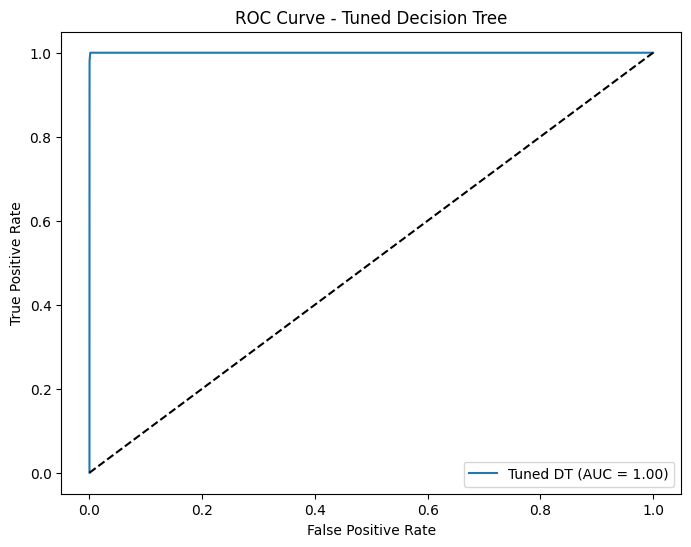

In [45]:
y_pred2 = best_dt2.predict(X_test)
y_proba2 = best_dt2.predict_proba(X_test)[:, 1]

ConfusionMatrixDisplay.from_estimator(best_dt2, X_test, y_test,
    display_labels=['Not Study Music', 'Study Music'], colorbar=False)
plt.title('Confusion Matrix - Tuned Decision Tree')
plt.show()

print(classification_report(y_test, y_pred2, target_names=['Not Study Music', 'Study Music']))

fpr2, tpr2, _ = roc_curve(y_test, y_proba2)
auc2 = roc_auc_score(y_test, y_proba2)
plt.figure(figsize=(8,6))
plt.plot(fpr2, tpr2, label=f'Tuned DT (AUC = {auc2:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Tuned Decision Tree')
plt.legend()
plt.show()

### Confusion Matrix, Classification Report & ROC Curve analysis

The tuned decision tree improved over Model 1 by reducing overfitting while maintaining strong performance. The confusion matrix shows only 145 false positives and zero false  negatives, correctly identifying all 8,263 study music songs.

The classification report shows perfect scores for "Not Study Music" and near-perfect  scores for "Study Music" with a precision of 0.98 and recall of 1.00, giving an overall accuracy of 1.00.

The ROC curve still shows a perfect AUC of 0.99, meaning the constraints helped reduce errors in the confusion matrix without hurting the model's ability to separate the two 
classes. This is a better result than Model 1 as the model is now making a small number of mistakes rather than zero, which is more realistic and less likely to be pure memorization.

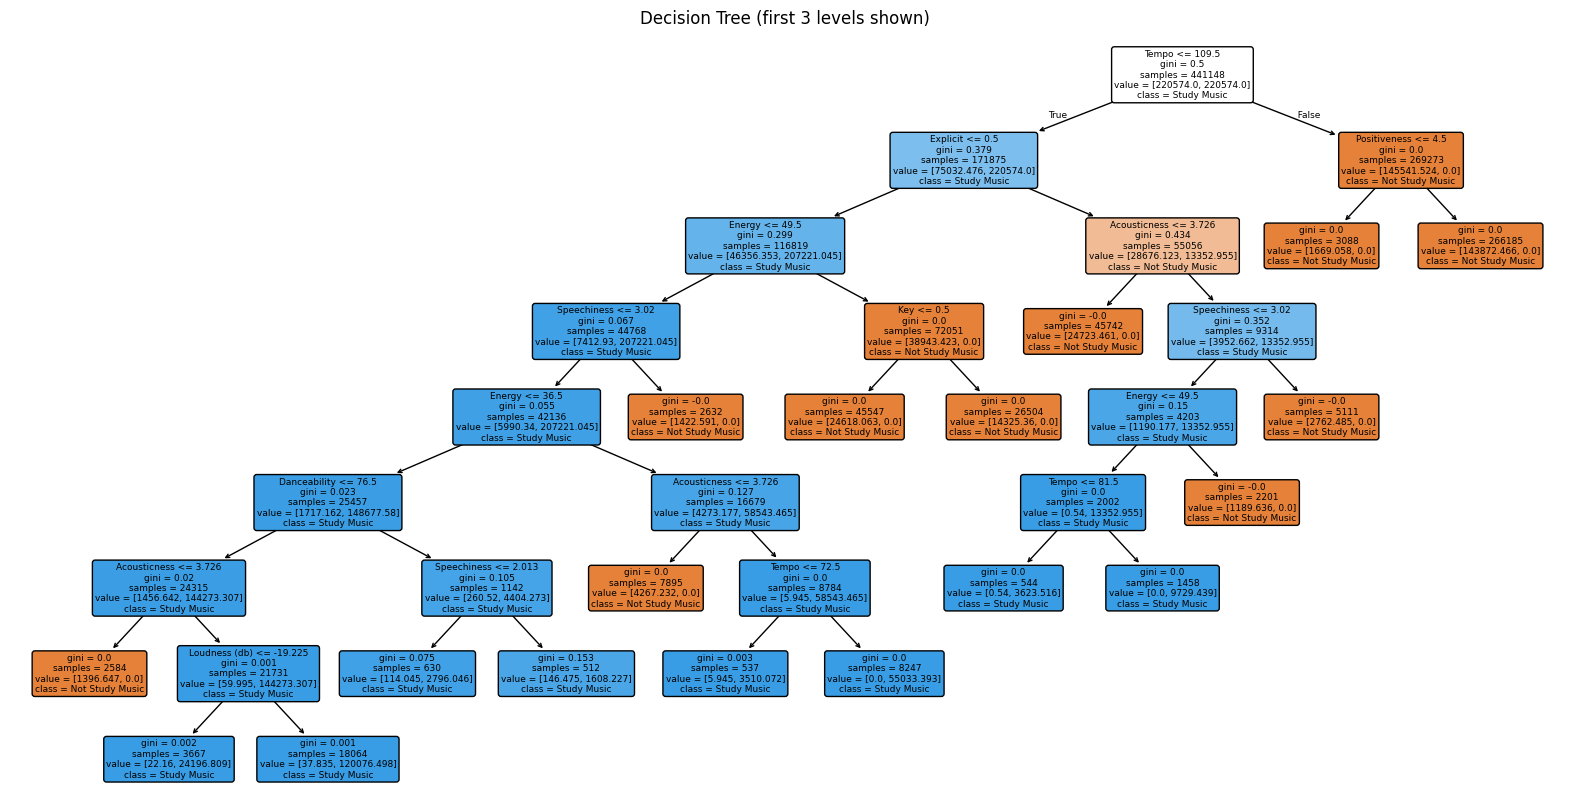

In [46]:
# get feature names in the order the tree saw them
feat_names = best_dt2.named_steps['prep'].get_feature_names_out().tolist()
feat_names = [n.split('__')[-1] for n in feat_names]

# tree visualization
plt.figure(figsize=(20,10))
plot_tree(best_clf2, feature_names=feat_names,
          class_names=['Not Study Music', 'Study Music'],
          filled=True, rounded=True, max_depth=8)
plt.title('Decision Tree (first 3 levels shown)')
plt.show()

### Feature Importance

Tempo (0.49), Energy (0.29), and Acousticness (0.10) were the three most important features, accounting for almost all of the model's decisions. Features like Emotion, Time Signature, and Instrumentalness had zero importance and contributed nothing to  the predictions.

### Model 3 vs Model 4 - Decision Tree Comparison

Model 3 (basic decision tree) overfit the data, achieving perfect scores across all metrics by memorizing the training data rather than learning real patterns. Acousticness dominated the splits with an importance of 0.66, meaning the model was essentially just asking "is this song acoustic?" at every decision.

Model 4 (tuned decision tree) addressed this by adding min_samples_leaf, max_depth, and max_features constraints. This forced the tree to spread its decisions across multiple features,  tempo (0.49), energy (0.29), acousticness (0.10), explicit (0.08), and speechiness (0.03). The result is a more realistic model that makes 145 mistakes instead of zero, and tells a more complete story about study music — it's not just acoustic songs, it's slow, calm, clean, and not too wordy songs.

## Model 5 - Random Forest

In [47]:
#resplit 
# Train / test split — 80/20, stratified so class ratios are preserved 
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [48]:
# editthe pipeline1 for Random Forest Classifier

pipeline1 = Pipeline(steps=[
    ('prep', X_raw),
    ('model', RandomForestClassifier(random_state=42))
])

# fit the data into pipeline
pipeline1.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical_features', ...), ('numeric_features', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the dif

In [49]:
# new predictions  
forest_prediction = pipeline1.predict(X_test)
forest_probability = pipeline1.predict_proba(X_test)

In [50]:
# new results dataframe 
forest_results = pd.DataFrame({
    'target': y_test,
    'pred': forest_prediction,
    'prob_not_good_for_study': forest_probability[:, 0], # first column
    'prob_good_for_study': forest_probability[:, 1] # second column
})

In [51]:
# view results
forest_results.head()

,target,pred,prob_not_good_for_study,prob_good_for_study
131919,0,0,1.00,0.00
149163,0,0,1.00,0.00
548637,0,0,1.00,0.00
150040,0,0,1.00,0.00
464540,1,1,0.01,0.99


The table above shows the first five predictions made by the Random Forest model on the test set. Every prediction in this sample is correct and highly confident — the model assigns probabilities close to 0 or 1 with very little uncertainty in between.

For songs that are not good for study, the model predicts 100% probability of "not good." For songs that are good for study, the model predicts 99% probability of "study music." The model is not second guessing itself at all, which is consistent with the near-perfect confusion matrix and 0.99 AUC score seen earlier.

## Model 5 Evaluation

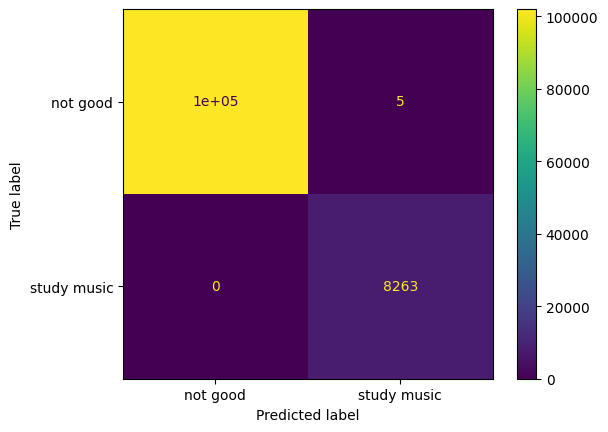

In [52]:
metrics.ConfusionMatrixDisplay.from_predictions(y_test, forest_prediction, display_labels=['not good', 'study music'])

### Confusion matrix analysis
The confusion matrix shows that the Random Forest model performed almost perfectly.
It correctly identified all 8,263 study music songs and only misclassified 5 out of
102,024 non-study songs, meaning the model made just 5 mistakes total.

In [53]:
print(metrics.classification_report(y_test, forest_prediction, target_names=['not good', 'study music'])) 

              precision    recall  f1-score   support

    not good       1.00      1.00      1.00    102024
 study music       1.00      1.00      1.00      8263

    accuracy                           1.00    110287
   macro avg       1.00      1.00      1.00    110287
weighted avg       1.00      1.00      1.00    110287



### Classification report analysis
The classification report confirms the strong performance seen in the confusion matrix.
Precision, recall, and F1-score are all 1.00 for both classes, with an overall accuracy
of 100% across all 110,287 test predictions. This makes the Random Forest the strongest
performing model in this project.

### Key takeaway from model 5

The Random Forest model performed extremely well, making only 5 mistakes out of 110,287 
predictions. It was highly confident in its predictions and correctly identified every 
single study music song. While a perfect score is always worth questioning, the results 
were consistent across both classes which suggests the model found real patterns in the 
data rather than just memorizing it.

# Conclusion

This project set out to answer **whether audio features *alone* can predict if a song is good for studying** . Platforms like Spotify rely heavily on audio characteristics to curate playlists and recommend music based on mood and listening habits. If audio features can reliably identify study music, it could help improve playlist recommendations like "study mode" or "focus flow" with greater precision, ultimately leading to better  user experience and more listening hours.

After exploring the dataset we considered several different prediction approaches. We  ultimately chose binary classification because emotion in music is highly subjective, what feels calming to one person may feel boring to another. Predicting a specific  emotion a song would cause proved too ambiguous and inconsistent to model reliably. A binary yes or no prediction of whether a song is good for studying gave us a cleaner and more answerable question. 

The dataset presented an immediate challenge, only 7% of songs were labeled as good for studying, making it heavily imbalanced. This required stratified train/test splits and class balancing across models to ensure the minority class was not ignored.

Early correlation analysis showed that **acousticness was strongly tied to the study music label**. While useful, this created a problem in the decision tree models where acousticness 
dominated every split. By adding **max_features** to the tuned decision tree, we forced the model to consider other features, which revealed that study music is **better** described by 
a combination of low tempo, low energy, non-explicit content, and low speechiness, not just acousticness alone.

Across all five models (2 logistic regression, 2 decision trees, and 1 random forrest), performance was consistently strong with AUC scores at or near 0.99. The **Random Forest was the best overall model**, making only 5 mistakes out of 110,287 predictions. The logistic regression models were very solid, however they showed clear signs of overfitting.

For future work, it would be worth investigating whether the "Good for Work/Study" label in the original dataset was itself derived from audio features, which could explain the 
near-perfect scores across all models. Additionally, incorporating user listening behavior or personal preference data could produce a more realistic and generalizable model, since 
audio features alone may not capture the full picture of what makes a song good for studying.

Overall, this project demonstrates that audio features are strong predictors of whether a song is good for studying, and that with the right preprocessing and model tuning, a reliable classification system can be built from data alone.

# Team Contribution

All team members - Natalie Schweickert, Mackenzie Kleczynski, and Audrey Stelle - contributed equally to this project. We all contributed to the question and background information section, eda, and conclusion. Natalie Schweickert did logistic regression, Mackenzie Kleczynski did Decision Trees, and Audrey Stelle did Random Rorest Classifier. 